## Imports

In [42]:
import warnings
warnings.filterwarnings('ignore')

import sys
import subprocess
import importlib

def _ensure(package_name: str, import_name: str = None):
    mod_name = import_name or package_name
    try:
        importlib.import_module(mod_name)
        return False
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        importlib.invalidate_caches()
        importlib.import_module(mod_name)
        return True

_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "seaborn": "seaborn",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "nltk": "nltk",
    "openpyxl": "openpyxl",
    "gensim": "gensim",
    "statsmodels": "statsmodels",
    "xgboost": "xgboost",
    "pickle": "pickle",
    "transformers": "transformers",
    "tensorflow": "tensorflow",
    "hashlib": "hashlib",
    "dataclasses": "dataclasses",
    "pathlib": "pathlib",
}

_installed = {}
for module_name, pip_name in _packages.items():
    _installed[module_name] = _ensure(pip_name, module_name)


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from gensim.models import Word2Vec
from xgboost import XGBClassifier

from typing import Dict, Tuple

from transformers import logging as hf_logging, RobertaTokenizer, TFRobertaModel

from dataclasses import dataclass

import tensorflow as tf

import math, random

import re, pickle, hashlib
from pathlib import Path

# Download required NLTK resources (quiet)
nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("stopwords", quiet=True)

hf_logging.set_verbosity_error()
tf.get_logger().setLevel("ERROR")
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

## Helper Functions

In [43]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text: str, remove_stopwords: bool = True) -> str:
    # Normalize whitespace and lowercase
    s = " ".join(str(text).split()).lower()

    # Remove URLs & email/user mentions
    s = re.sub(r'http\S+|www\S+|@\S+', '', s)

    # Remove special characters, punctuation, and numbers (keep letters and spaces)
    s = re.sub(r'[^a-zA-Z\s]', ' ', s)

    # Tokenize
    tokens = word_tokenize(s)

    # Remove stopwords & lemmatize (or just lemmatize if remove_stopwords=False)
    if remove_stopwords:
        tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    else:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

def load_lf_xlsx(xlsx_path: str) -> pd.DataFrame:
    xl = pd.read_excel(xlsx_path)
    
    X = xl.drop(columns=['label'])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    lf = pd.DataFrame(X_scaled, columns=X.columns)

    return lf.reset_index(drop=True) 

In [44]:
# checking dataset potential issues
def check_dataset(word_embeddings, linguistic_features, combined_features, y_train):
    print(f"Word embeddings shape: {word_embeddings.shape}")
    print(f"Linguistic features shape: {linguistic_features.shape}")
    print(f"Combined features shape: {combined_features.shape}")
    print(f"Training samples: {len(y_train)}")
    print(f"Total features: {combined_features.shape[1]}")
    print(f"Features vs Samples ratio: {combined_features.shape[1] / len(y_train):.2f}")

    # Check for potential issues
    print("\nChecking for potential multicollinearity issues:")
    print(f"Any NaN values: {np.isnan(combined_features).any()}")
    print(f"Any infinite values: {np.isinf(combined_features).any()}")

    # Check feature variance
    feature_variances = np.var(combined_features, axis=0)
    low_variance_features = np.sum(feature_variances < 1e-10)
    print(f"Features with very low variance (< 1e-10): {low_variance_features}")

    # Check condition number (indicates multicollinearity)
    try:
        cond_number = np.linalg.cond(combined_features)
        print(f"Condition number: {cond_number:.2e}")
        if cond_number > 1e12:
            print("High condition number suggests severe multicollinearity")
    except:
        print("Could not compute condition number - likely singular matrix")

In [45]:
# logistic regression model with grid search and cross-validation
def train_logistic_regression(X_train, y_train, model_name):
    # check if model already exists in all_models/ folder
    try:
        with open(f'all_models/{model_name}_logistic_regression.pkl', 'rb') as f:
            model = pickle.load(f)
            print(f"Loaded existing model from all_models/{model_name}_logistic_regression.pkl")
            return model
    except FileNotFoundError:
        print("No existing model found, training a new one...")
        param_grid = {
            'C': [0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2']
        }

        lr = LogisticRegression(max_iter=1000, random_state=42)
        grid_search = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

        best_model = grid_search.best_estimator_
        with open(f'all_models/{model_name}_logistic_regression.pkl', 'wb') as f:
            pickle.dump(best_model, f)
            print(f"Saved model to all_models/{model_name}_logistic_regression.pkl")
        return best_model

In [46]:
# svm model with grid search and cross-validation
def train_svm(X_train, y_train, model_name):
    # check if model already exists in all_models/ folder
    try:
        with open(f'all_models/{model_name}_svm.pkl', 'rb') as f:
            model = pickle.load(f)
            print(f"Loaded existing model from all_models/{model_name}_svm.pkl")
            return model
    except FileNotFoundError:
        print("No existing model found, training a new one...")
        param_grid = {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }

        svm = SVC(random_state=42)
        grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

        best_model = grid_search.best_estimator_
        
        # saving the best model
        with open(f'all_models/{model_name}_svm.pkl', 'wb') as f:
            pickle.dump(best_model, f)
            print(f"Saved model to all_models/{model_name}_svm.pkl")
        return best_model

In [47]:
# xgboost classifier with grid search and cross-validation
def train_xgboost(X_train, y_train, model_name):
    # check if model already exists in all_models/ folder
    try:
        with open(f'all_models/{model_name}_xgboost.pkl', 'rb') as f:
            model = pickle.load(f)
            print(f"Loaded existing model from all_models/{model_name}_xgboost.pkl")
            return model
    except FileNotFoundError:
        print("No existing model found, training a new one...")
        param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 1.0]
        }

        xgb = XGBClassifier(random_state=42, eval_metric='logloss')
        grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

        best_model = grid_search.best_estimator_
        
        with open(f'all_models/{model_name}_xgboost.pkl', 'wb') as f:
            pickle.dump(best_model, f)
            print(f"Saved model to all_models/{model_name}_xgboost.pkl")

        return best_model

In [48]:
# model evaluation function
def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)

    if type(y_pred[0]) != int:
        y_pred = (y_pred > 0.5).astype("int32") # for tf-based models
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)
    
    # Confusion matrix heatmap
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title("Confusion Matrix - " + model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [49]:
def plot_auc_curve(model, X_test, y_test, model_name="Model", pos_label=1):
    y_true = np.array(y_test).astype(int).ravel()

    y_score = model.predict(X_test)

    if type(y_score[0]) != int:
        y_score = (y_score > 0.5).astype("int32") # for tf-based models

    # Compute ROC
    fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=pos_label)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color="C0", lw=2, label=f"{model_name} (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Chance")
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {model_name}")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    return fpr, tpr, roc_auc

In [143]:
def plot_model_accuracies(
    models_w2v,
    models_tfidf,
    Xte_w2v,
    Xte_tfidf,
    yte_w2v,
    yte_tfidf,
    model_names=None,
    title="Model Accuracy by Representation",
    figsize=(9, 4.5),
    external_paper_accuracy=None # number
):
    def _get_acc(model, X, y):
        y_pred = model.predict(X)
        return accuracy_score(y, np.ravel(y_pred).astype(int))
    
    n = max(len(models_w2v), len(models_tfidf))
    if model_names is None:
        model_names = [f"Model {i+1}" for i in range(n)]
    if len(model_names) != n:
        raise ValueError("Length of model_names must equal number of models being compared.")
    
    acc_w2v = [_get_acc(m, Xte_w2v, yte_w2v) for m in models_w2v]
    acc_tfidf = [_get_acc(m, Xte_tfidf, yte_tfidf) for m in models_tfidf]
    
    y_pos = np.arange(n)
    bar_h = 0.35
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(y_pos - bar_h/2, acc_w2v, height=bar_h, label="Word2Vec", color="C0")
    ax.barh(y_pos + bar_h/2, acc_tfidf, height=bar_h, label="TF-IDF", color="C1")

    # External paper accuracy
    if external_paper_accuracy is not None:
        ax.plot([external_paper_accuracy, external_paper_accuracy], [-1, n], color="gray", linestyle="--", alpha=0.7)
        ax.text(external_paper_accuracy + 0.01, n - 0.5, f"Paper: {external_paper_accuracy:.3f}", rotation=90, color="gray", fontsize=9)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(model_names)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("Accuracy")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
    ax.legend(loc="lower right")
    
    # Annotate bars
    for i, v in enumerate(acc_w2v):
        if not np.isnan(v):
            ax.text(v + 0.01, y_pos[i] - bar_h/2, f"{v:.3f}", va="center", fontsize=9)
    for i, v in enumerate(acc_tfidf):
        if not np.isnan(v):
            ax.text(v + 0.01, y_pos[i] + bar_h/2, f"{v:.3f}", va="center", fontsize=9)
    
    plt.tight_layout()
    return fig, ax


In [51]:
def plot_model_aucs(
    models_w2v,
    models_tfidf,
    Xte_w2v,
    Xte_tfidf,
    yte_w2v,
    yte_tfidf,
    model_names=None,
    title="ROC Curves by Representation",
    figsize=(8, 6),
    pos_label=1,
):
    def _get_score(model, X):
        return model.predict(X)

    n = max(len(models_w2v), len(models_tfidf))
    if model_names is None:
        model_names = [f"Model {i+1}" for i in range(n)]
    if len(model_names) != n:
        raise ValueError("Length of model_names must equal number of models being compared.")

    y_w2v = np.array(yte_w2v).astype(int).ravel()
    y_tfidf = np.array(yte_tfidf).astype(int).ravel()

    fig, ax = plt.subplots(figsize=figsize)

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    color_count = len(colors)

    plotted_any = False
    for i in range(n):
        name = model_names[i]

        # Word2Vec
        if i < len(models_w2v) and models_w2v[i] is not None:
            try:
                score_w = _get_score(models_w2v[i], Xte_w2v)
                fpr_w, tpr_w, _ = roc_curve(y_w2v, score_w, pos_label=pos_label)
                auc_w = auc(fpr_w, tpr_w)
                c = colors[(2 * i) % color_count]
                ax.plot(fpr_w, tpr_w, label=f"{name} — W2V (AUC={auc_w:.3f})", color=c, lw=2, linestyle="-")
                plotted_any = True
            except Exception as e:
                ax.text(0.02, 0.9 - i * 0.03, f"W2V {name} failed: {e}", transform=ax.transAxes, fontsize=8, color="C0")

        # TF-IDF
        if i < len(models_tfidf) and models_tfidf[i] is not None:
            try:
                score_t = _get_score(models_tfidf[i], Xte_tfidf)
                fpr_t, tpr_t, _ = roc_curve(y_tfidf, score_t, pos_label=pos_label)
                auc_t = auc(fpr_t, tpr_t)
                c = colors[(2 * i + 1) % color_count]
                ax.plot(fpr_t, tpr_t, label=f"{name} — TF-IDF (AUC={auc_t:.3f})", color=c, lw=2, linestyle="--")
                plotted_any = True
            except Exception as e:
                ax.text(0.02, 0.9 - i * 0.03 - 0.02, f"TFIDF {name} failed: {e}", transform=ax.transAxes, fontsize=8, color="C1")

    if not plotted_any:
        ax.text(0.5, 0.5, "No curves were plotted", ha="center", va="center", transform=ax.transAxes)

    ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Chance")
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    return fig, ax

In [52]:
def plot_model_accuracies_ranked(
    models_by_dataset,
    Xte_by_dataset,
    yte_by_dataset,
    model_names=None,
    dataset_labels=None,
    title="All Models - Accuracy (desc)",
    figsize=(12, 6),
):
    num_dsets = len(models_by_dataset)
    if not (len(Xte_by_dataset) == num_dsets == len(yte_by_dataset)):
        raise ValueError("models_by_dataset, Xte_by_dataset, yte_by_dataset must have same number of datasets.")

    # default dataset labels
    if dataset_labels is None:
        dataset_labels = [f"Dataset {i+1}" for i in range(num_dsets)]

    # helper to resolve a name for (dataset i, model j)
    def name_for(di, mi):
        if model_names is None:
            return f"{dataset_labels[di]} • Model {mi+1}"
        # nested or flat
        if isinstance(model_names[0], (list, tuple)):
            if di < len(model_names) and mi < len(model_names[di]):
                return str(model_names[di][mi])
            return f"{dataset_labels[di]} • Model {mi+1}"
        else:
            # flat slot names
            if mi < len(model_names):
                return f"{dataset_labels[di]} • {model_names[mi]}"
            return f"{dataset_labels[di]} • Model {mi+1}"

    entries = []  # (label, acc, dataset_index)
    for di in range(num_dsets):
        models = models_by_dataset[di]
        Xd = Xte_by_dataset[di]
        yd = yte_by_dataset[di]
        for mi, mdl in enumerate(models):
            if mdl is None:
                continue
            # pick per-model X/y if provided as lists; otherwise reuse dataset-level
            Xmi = Xd[mi] if isinstance(Xd, (list, tuple)) else Xd
            ymi = yd[mi] if isinstance(yd, (list, tuple)) else yd
            try:
                y_pred = mdl.predict(Xmi)
                y_pred = np.asarray(y_pred)
                if y_pred.ndim > 1:
                    y_pred = y_pred.ravel()
                # threshold floats (Keras) to ints
                if not np.issubdtype(y_pred.dtype, np.integer):
                    y_pred = (y_pred > 0.5).astype(int)
                acc = accuracy_score(ymi, y_pred.astype(int))
            except Exception:
                acc = np.nan
            entries.append((name_for(di, mi), acc, di))

    entries_sorted = sorted(entries, key=lambda x: (-np.nan_to_num(x[1], nan=-1.0), x[0]))
    names  = [e[0] for e in entries_sorted]
    accs   = [e[1] for e in entries_sorted]
    dsets  = [e[2] for e in entries_sorted]

    n = len(entries_sorted)
    fig_h = max(figsize[1], 0.45 * n + 1.5) 
    fig, ax = plt.subplots(figsize=(figsize[0], fig_h))

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    bar_colors = [colors[i % len(colors)] for i in dsets]

    ypos = np.arange(n)
    bars = ax.barh(ypos, accs, color=bar_colors, alpha=0.9)

    # annotate: model name inside bar, accuracy at the end
    for i, (bar, name, v) in enumerate(zip(bars, names, accs)):
        y = bar.get_y() + bar.get_height() / 2.0
        # model name inside the bar (toward the left portion of each bar)
        if np.isnan(v):
            x_name = 0.01
            name_color = "black"
        else:
            x_name = max(0.01, min(v * 0.15, max(v - 0.05, 0.01)))
            name_color = "white" if v >= 0.35 else "black"
        ax.text(x_name, y, name, va="center", ha="left", fontsize=9, color=name_color)

        # numeric value at the bar end
        if not np.isnan(v):
            x_val = min(v + 0.01, 0.995)
            ha = "left" if v <= 0.96 else "right"
            if ha == "right":
                x_val = v - 0.01
            ax.text(x_val, y, f"{v:.3f}", va="center", ha=ha, fontsize=9, color="black")

    # style
    ax.set_yticks([])
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("Accuracy")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    return fig, ax, np.array(accs)

In [148]:
def plot_top_linguistic_features(df: pd.DataFrame, y, top_n: int = 10) :
    if len(y) != len(df):
        raise ValueError(f"Length of y ({len(y)}) must match number of rows in df ({len(df)}).")

    y = pd.Series(y, index=df.index).astype(float)
    uniq = pd.Series(y.dropna().unique())
    if not set(uniq).issubset({0.0, 1.0}):
        raise ValueError("y must contain only 0/1 values (already numeric).")

    # Use only numeric features; convert bools to ints
    X = df.copy()
    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    if not num_cols:
        raise ValueError("No numeric feature columns found.")

    # Drop constant columns
    num_cols = [c for c in num_cols if X[c].nunique(dropna=True) > 1]
    if not num_cols:
        raise ValueError("All numeric features are constant.")

    # Compute point-biserial correlations (Pearson with binary y)
    corrs = {}
    for col in num_cols:
        x = pd.to_numeric(X[col], errors="coerce")
        mask = ~(x.isna() | y.isna())
        if mask.sum() >= 6 and x[mask].std(ddof=0) > 0:
            r = np.corrcoef(x[mask], y[mask])[0, 1]
            if np.isfinite(r):
                corrs[col] = r

    if not corrs:
        raise ValueError("No valid correlations could be computed.")

    s = pd.Series(corrs)
    top = s.abs().sort_values(ascending=False).head(top_n)
    top_signed = s.loc[top.index] # keep sign for annotation

    # Plot (no title, no saving)
    fig, ax = plt.subplots(figsize=(10, 7))
    ypos = np.arange(len(top_signed))
    ax.barh(ypos, np.abs(top_signed.values)) # no explicit colors/styles
    ax.set_yticks(ypos, labels=top_signed.index)
    ax.set_xlabel("Point-biserial r (|r|)")

    # Annotate with signed r
    for i, r in enumerate(top_signed.values):
        ax.text(abs(r), i, f" {r:+.2f}", va='center', fontsize=9)

    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()

## Models

### Dataset Loader

In [53]:
def load_dataset(csv_path: str, lf_path: str):
    df = pd.read_csv(csv_path)

    # taking only text and label columns, dropping rows with missing values
    df = df[["text", "label"]].dropna()

    # Preprocess text: normalize, remove stopwords, lemmatize
    df["clean_text"] = df["text"].map(lambda s: preprocess(s, remove_stopwords=True))

    # Tokenized sentences
    tokenized_sentences = df["clean_text"].apply(lambda x: x.split())

    # Labels
    y = df["label"].astype(int)

    # Linguistic features
    lf = load_lf_xlsx(lf_path)

    # Drop original label columns
    df = df.drop(columns=["label"])

    return {
        "tokenized_sentences": tokenized_sentences,
        "dataset": df,
        "output_labels": y,
        "linguistic_features": lf
    }

In [54]:
def create_train_test_split(X_data, y_data, random_state=42, test_size = 0.3):
    return train_test_split(X_data, y_data, test_size=test_size, random_state=random_state)

### Mcintire Dataset

In [55]:
mcinter_dataset_path = "Dataset/Mcintire_DataSet.csv"
mcinter_lf_path = "Dataset/linguistic_features/arrays_Mcintire.xlsx"

mcinter_data = load_dataset(mcinter_dataset_path, mcinter_lf_path)

mcinter_df = mcinter_data["dataset"]
mcinter_y = mcinter_data["output_labels"]
mcinter_lf = mcinter_data["linguistic_features"]
mcinter_tokenized = mcinter_data["tokenized_sentences"]

mcinter_df.shape, mcinter_y.shape, mcinter_lf.shape, mcinter_tokenized.shape

((6335, 2), (6335,), (6335, 80), (6335,))

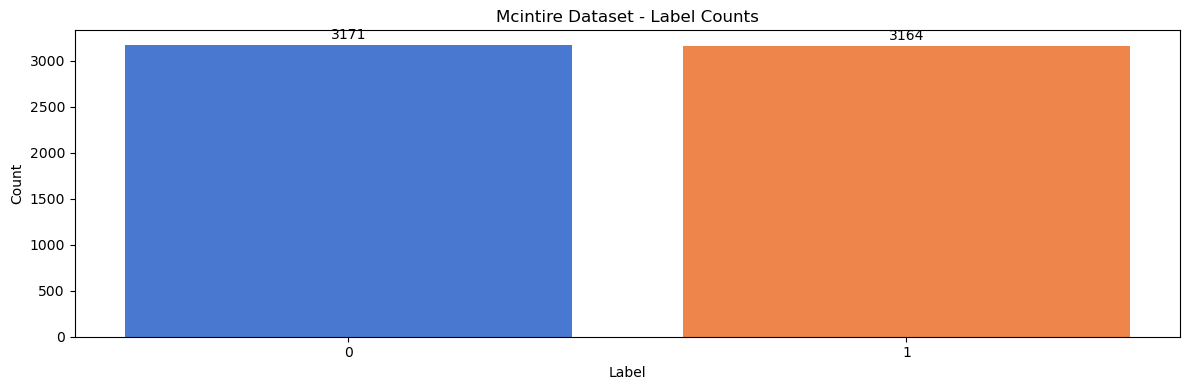

In [56]:
counts = mcinter_y.value_counts().sort_index()

fig, axes = plt.subplots(1, 1, figsize=(12, 4))

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

# Bar plot
colors = sns.color_palette("muted", n_colors=len(counts))
ax.bar(counts.index.astype(str), counts.values, color=colors)
ax.set_title("Mcintire Dataset - Label Counts")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.max() * 0.01, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

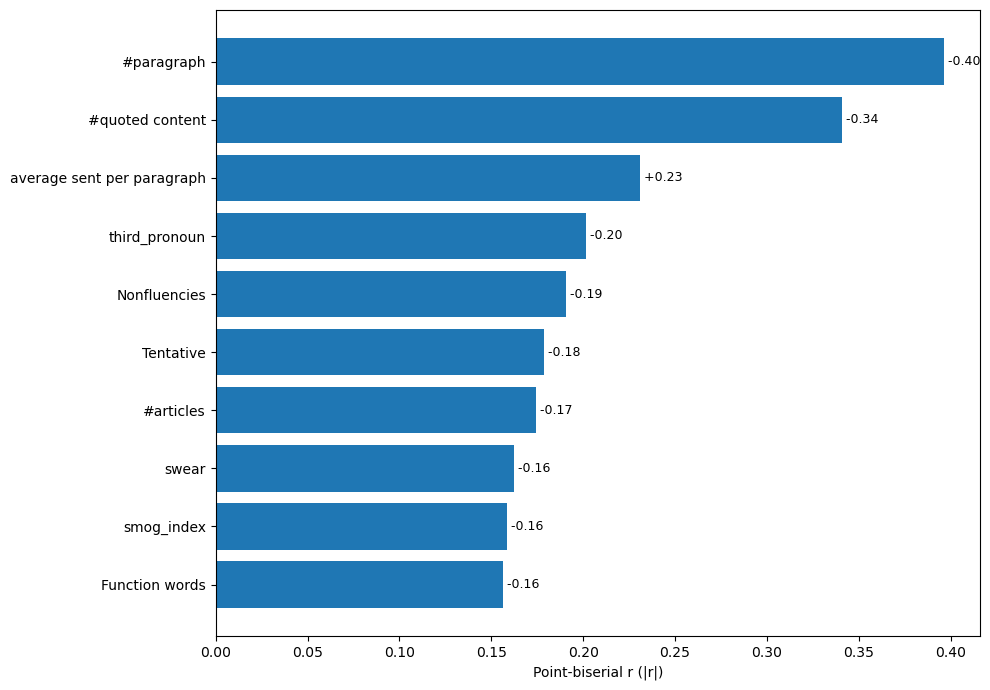

In [149]:
plot_top_linguistic_features(mcinter_lf, mcinter_y, top_n=10)

#### Word2Vec Embeddings

In [57]:
# Word2Vec model training and embedding extraction

mcinter_word2vec = Word2Vec(sentences=mcinter_tokenized, vector_size=100, window=5, min_count=1, workers=4)

mcinter_word_embeddings = np.array([np.mean([mcinter_word2vec.wv[word] for word in words if word in mcinter_word2vec.wv] or [np.zeros(100)], axis=0) for words in mcinter_tokenized])

In [58]:
# train-test split with combined features

X_combined = np.concatenate((mcinter_word_embeddings, mcinter_lf.values), axis=1)

X_train_w2v_mc, X_test_w2v_mc, y_train_w2v_mc, y_test_w2v_mc = create_train_test_split(X_combined, mcinter_y, random_state=42, test_size=0.3)

In [59]:
# checking the dimensions and potential issues
check_dataset(mcinter_word_embeddings, mcinter_lf, X_combined, y_train_w2v_mc)

Word embeddings shape: (6335, 100)
Linguistic features shape: (6335, 80)
Combined features shape: (6335, 180)
Training samples: 4434
Total features: 180
Features vs Samples ratio: 0.04

Checking for potential multicollinearity issues:
Any NaN values: False
Any infinite values: False
Features with very low variance (< 1e-10): 1
Condition number: 2.38e+18
High condition number suggests severe multicollinearity


##### Logistic Regression

In [129]:
mcinter_logit_model = train_logistic_regression(X_train_w2v_mc, y_train_w2v_mc, model_name="mcinter")
print(mcinter_logit_model)
print(mcinter_logit_model.penalty)

Loaded existing model from all_models/mcinter_logistic_regression.pkl
LogisticRegression(C=1, max_iter=1000, random_state=42)
l2


Accuracy: 0.9248
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       933
           1       0.90      0.96      0.93       968

    accuracy                           0.92      1901
   macro avg       0.93      0.92      0.92      1901
weighted avg       0.93      0.92      0.92      1901



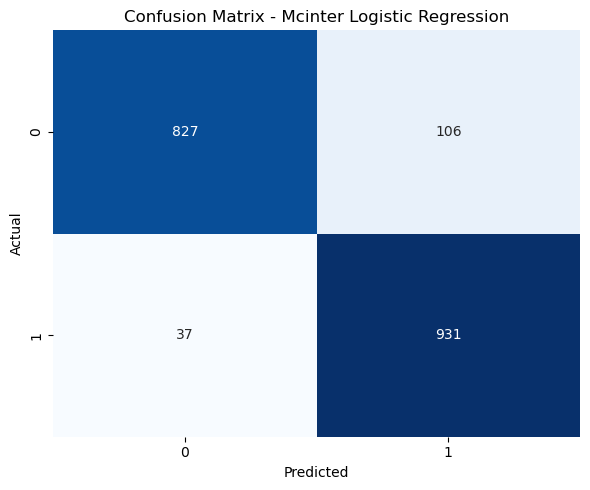

In [61]:
evaluate_model(mcinter_logit_model, X_test_w2v_mc, y_test_w2v_mc, model_name="Mcinter Logistic Regression")

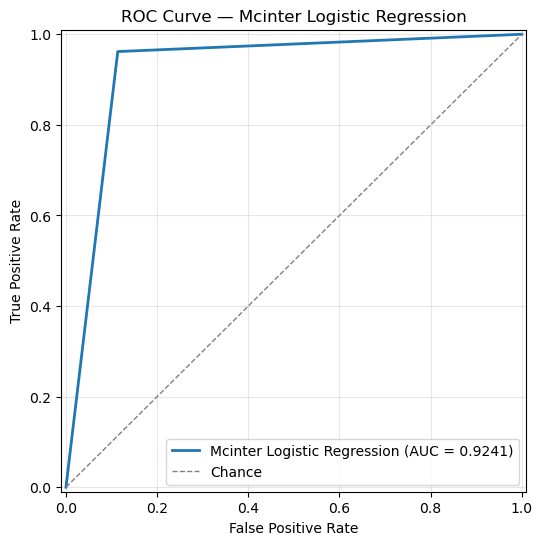

(array([0.      , 0.113612, 1.      ]),
 array([0.        , 0.96177686, 1.        ]),
 0.9240824276084433)

In [62]:
plot_auc_curve(mcinter_logit_model, X_test_w2v_mc, y_test_w2v_mc, "Mcinter Logistic Regression")

##### SVM

In [133]:
mcinter_svm_model = train_svm(X_train_w2v_mc, y_train_w2v_mc, model_name="mcinter")
print(mcinter_svm_model)
print(mcinter_svm_model.kernel)

Loaded existing model from all_models/mcinter_svm.pkl
SVC(C=10, gamma='auto', random_state=42)
rbf


Accuracy: 0.9390
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       933
           1       0.92      0.96      0.94       968

    accuracy                           0.94      1901
   macro avg       0.94      0.94      0.94      1901
weighted avg       0.94      0.94      0.94      1901



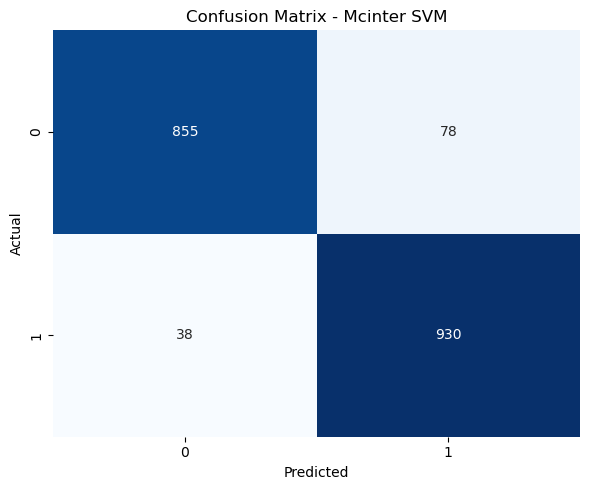

In [64]:
evaluate_model(mcinter_svm_model, X_test_w2v_mc, y_test_w2v_mc, model_name="Mcinter SVM")

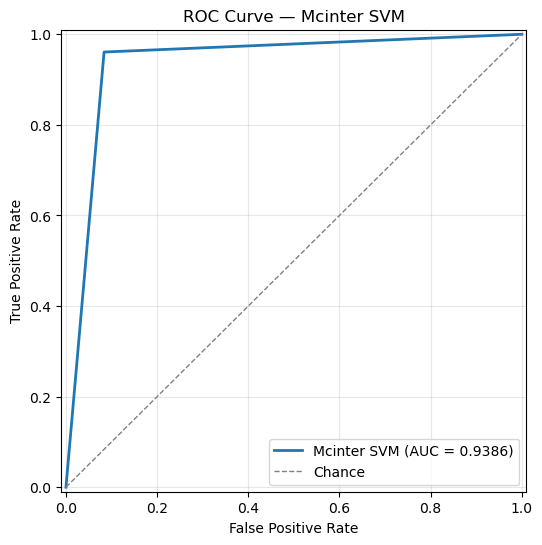

(array([0.        , 0.08360129, 1.        ]),
 array([0.       , 0.9607438, 1.       ]),
 0.9385712577396295)

In [65]:
plot_auc_curve(mcinter_svm_model, X_test_w2v_mc, y_test_w2v_mc, "Mcinter SVM")

##### XGBoost

In [139]:
mcinter_xgb_model = train_xgboost(X_train_w2v_mc, y_train_w2v_mc, model_name="mcinter")
print(mcinter_xgb_model)
print(mcinter_xgb_model.subsample)

Loaded existing model from all_models/mcinter_xgboost.pkl
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)
1.0


Accuracy: 0.9379
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       933
           1       0.92      0.96      0.94       968

    accuracy                           0.94      1901
   macro avg       0.94      0.94      0.94      1901
weighted avg       0.94      0.94      0.94      1901



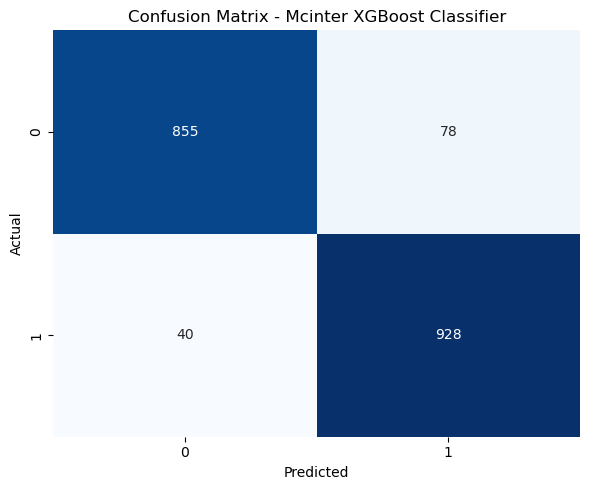

In [67]:
evaluate_model(mcinter_xgb_model, X_test_w2v_mc, y_test_w2v_mc, model_name="Mcinter XGBoost Classifier")

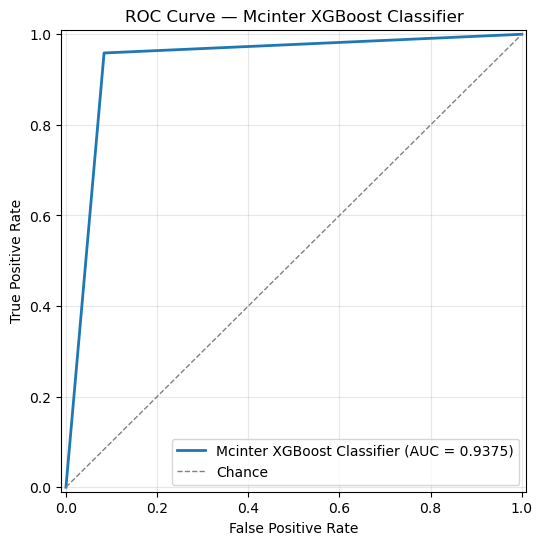

(array([0.        , 0.08360129, 1.        ]),
 array([0.        , 0.95867769, 1.        ]),
 0.9375381998883898)

In [68]:
plot_auc_curve(mcinter_xgb_model, X_test_w2v_mc, y_test_w2v_mc, "Mcinter XGBoost Classifier")

#### TFIDF Vectorizer Embeddings

In [69]:
mcinter_tfidf_vectorizer = TfidfVectorizer(max_features=5000, analyzer=lambda x: x)
mcinter_tfidf_embeddings = mcinter_tfidf_vectorizer.fit_transform(mcinter_tokenized).toarray()

In [70]:
X_combined = np.concatenate((mcinter_tfidf_embeddings, mcinter_lf.values), axis=1)

X_train_tfidf_mc, X_test_tfidf_mc, y_train_tfidf_mc, y_test_tfidf_mc = create_train_test_split(X_combined, mcinter_y, random_state=42, test_size=0.3)

##### Logistic Regression

In [130]:
mcinter_tfidf_logit_model = train_logistic_regression(X_train_tfidf_mc, y_train_tfidf_mc, model_name="mcinter_tfidf")
print(mcinter_tfidf_logit_model)
print(mcinter_tfidf_logit_model.penalty)

Loaded existing model from all_models/mcinter_tfidf_logistic_regression.pkl
LogisticRegression(C=100, max_iter=1000, random_state=42)
l2


Accuracy: 0.9537
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       933
           1       0.95      0.96      0.95       968

    accuracy                           0.95      1901
   macro avg       0.95      0.95      0.95      1901
weighted avg       0.95      0.95      0.95      1901



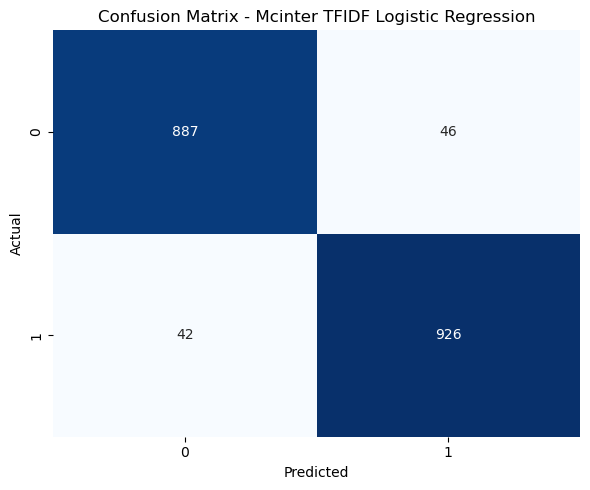

In [72]:
evaluate_model(mcinter_tfidf_logit_model, X_test_tfidf_mc, y_test_tfidf_mc, model_name="Mcinter TFIDF Logistic Regression")

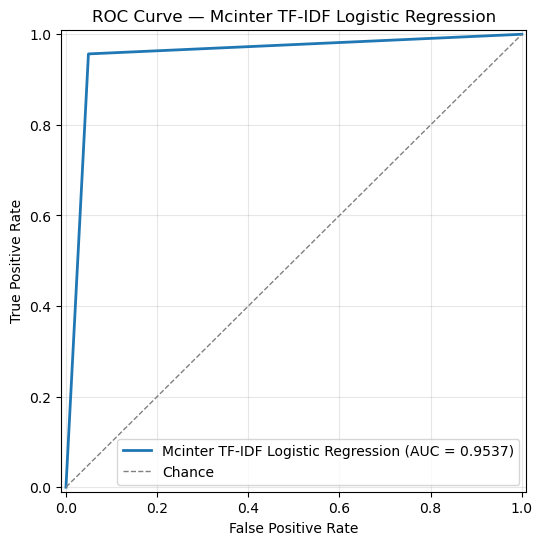

(array([0.        , 0.04930332, 1.        ]),
 array([0.        , 0.95661157, 1.        ]),
 0.9536541238163571)

In [73]:
plot_auc_curve(mcinter_tfidf_logit_model, X_test_tfidf_mc, y_test_tfidf_mc, "Mcinter TF-IDF Logistic Regression")

##### SVM

In [135]:
mcinter_svm_tfidf_model = train_svm(X_train_tfidf_mc, y_train_tfidf_mc, model_name="mcinter_tfidf")
print(mcinter_svm_tfidf_model)
print(mcinter_svm_tfidf_model.gamma)

Loaded existing model from all_models/mcinter_tfidf_svm.pkl
SVC(C=1, kernel='linear', random_state=42)
scale


Accuracy: 0.9484
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       933
           1       0.95      0.95      0.95       968

    accuracy                           0.95      1901
   macro avg       0.95      0.95      0.95      1901
weighted avg       0.95      0.95      0.95      1901



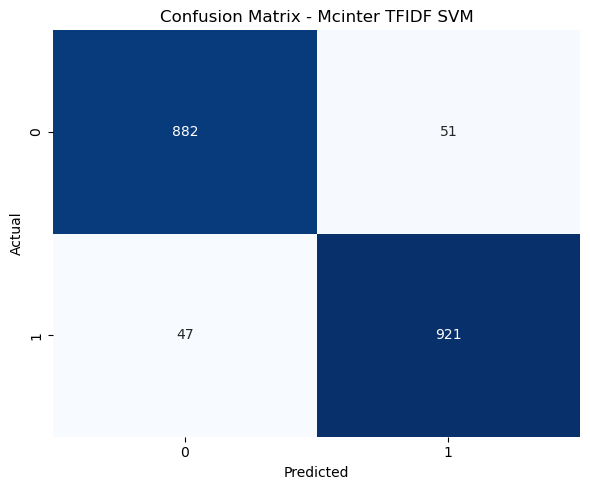

In [75]:
evaluate_model(mcinter_svm_tfidf_model, X_test_tfidf_mc, y_test_tfidf_mc, model_name="Mcinter TFIDF SVM")

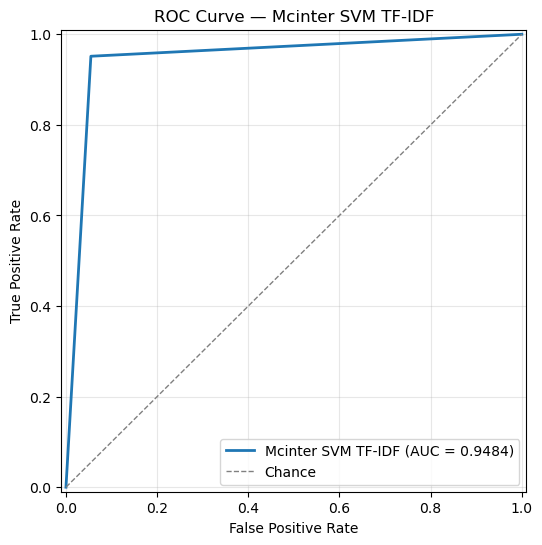

(array([0.        , 0.05466238, 1.        ]),
 array([0.        , 0.95144628, 1.        ]),
 0.9483919507852567)

In [76]:
plot_auc_curve(mcinter_svm_tfidf_model, X_test_tfidf_mc, y_test_tfidf_mc, "Mcinter SVM TF-IDF")

##### XGBoost Classifier

In [140]:
mcinter_xgb_tfidf_model = train_xgboost(X_train_tfidf_mc, y_train_tfidf_mc, model_name="mcinter_tfidf")
print(mcinter_xgb_tfidf_model)
print(mcinter_xgb_tfidf_model.subsample)

Loaded existing model from all_models/mcinter_tfidf_xgboost.pkl
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)
0.8


Accuracy: 0.9653
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       933
           1       0.96      0.97      0.97       968

    accuracy                           0.97      1901
   macro avg       0.97      0.97      0.97      1901
weighted avg       0.97      0.97      0.97      1901



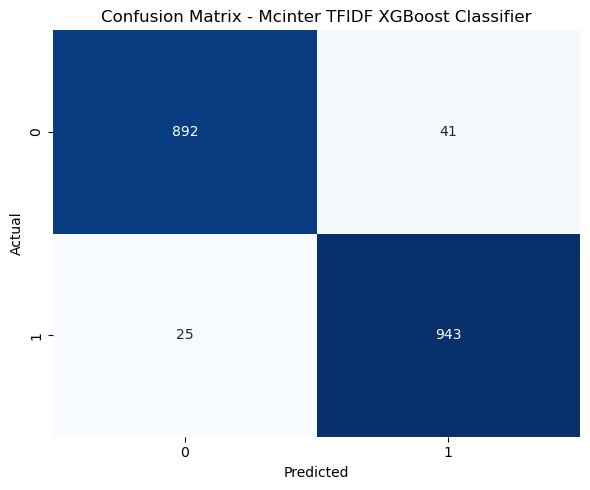

In [78]:
evaluate_model(mcinter_xgb_tfidf_model, X_test_tfidf_mc, y_test_tfidf_mc, model_name="Mcinter TFIDF XGBoost Classifier")

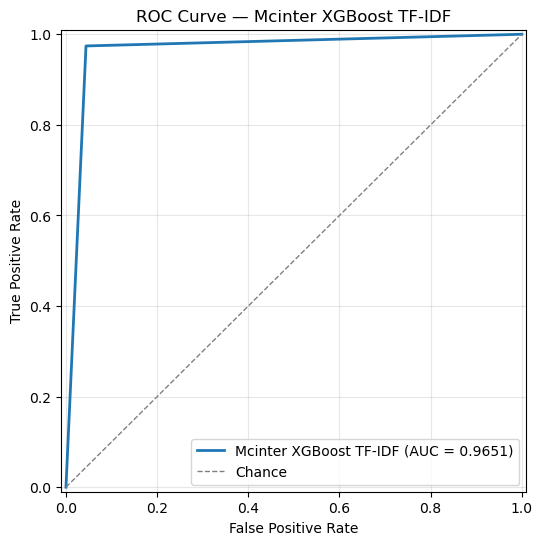

(array([0.        , 0.04394427, 1.        ]),
 array([0.        , 0.97417355, 1.        ]),
 0.9651146439548953)

In [79]:
plot_auc_curve(mcinter_xgb_tfidf_model, X_test_tfidf_mc, y_test_tfidf_mc, "Mcinter XGBoost TF-IDF")

##### Model Accuracy Comparison

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Mcintire Dataset - Model Accuracy Comparison'}, xlabel='Accuracy'>)

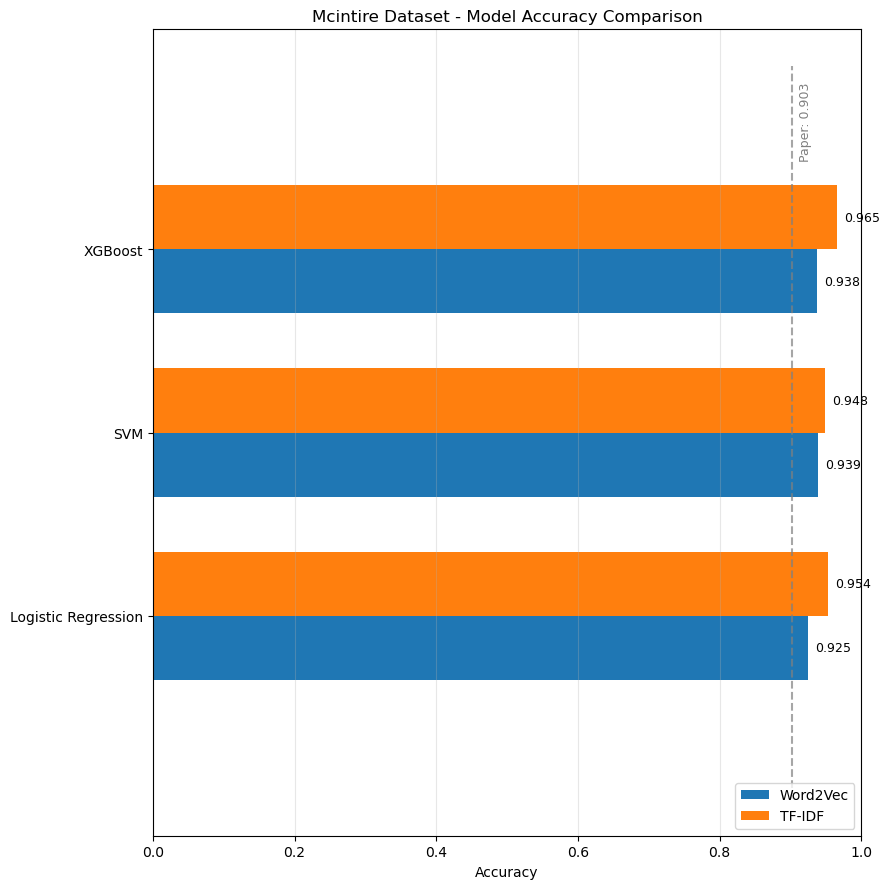

In [146]:
plot_model_accuracies(
    models_w2v=[mcinter_logit_model, mcinter_svm_model, mcinter_xgb_model],
    models_tfidf=[mcinter_tfidf_logit_model, mcinter_svm_tfidf_model, mcinter_xgb_tfidf_model],
    Xte_w2v=X_test_w2v_mc,
    Xte_tfidf=X_test_tfidf_mc,
    yte_w2v=y_test_w2v_mc,
    yte_tfidf=y_test_tfidf_mc,
    model_names=["Logistic Regression", "SVM", "XGBoost"],
    title="Mcintire Dataset - Model Accuracy Comparison",
    external_paper_accuracy=0.9026,
    figsize=(9, 9)
)

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Mcintire Dataset - ROC Curves Comparison'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>)

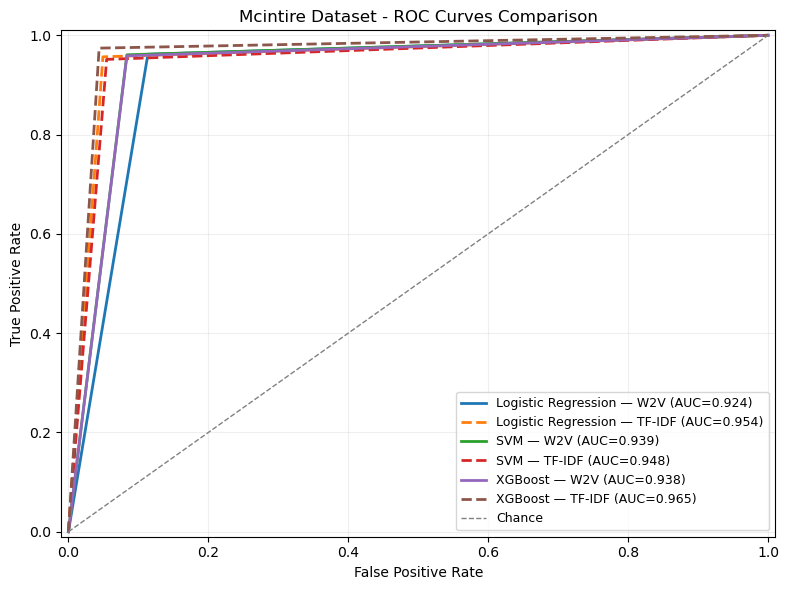

In [81]:
plot_model_aucs(
    models_w2v=[mcinter_logit_model, mcinter_svm_model, mcinter_xgb_model],
    models_tfidf=[mcinter_tfidf_logit_model, mcinter_svm_tfidf_model, mcinter_xgb_tfidf_model],
    Xte_w2v=X_test_w2v_mc,
    Xte_tfidf=X_test_tfidf_mc,
    yte_w2v=y_test_w2v_mc,
    yte_tfidf=y_test_tfidf_mc,
    model_names=["Logistic Regression", "SVM", "XGBoost"],
    title="Mcintire Dataset - ROC Curves Comparison"
)

### Kaggle Dataset

In [82]:
kaggle_dataset_path = "Dataset/Kaggle.csv"
kaggle_lf_path = "Dataset/linguistic_features/arrays_kaggle.xlsx"

kaggle_data = load_dataset(kaggle_dataset_path, kaggle_lf_path)

kaggle_df = kaggle_data["dataset"]
kaggle_y = kaggle_data["output_labels"]
kaggle_lf = kaggle_data["linguistic_features"]
kaggle_tokenized = kaggle_data["tokenized_sentences"]

kaggle_df.shape, kaggle_y.shape, kaggle_lf.shape, kaggle_tokenized.shape

((20761, 2), (20761,), (20761, 80), (20761,))

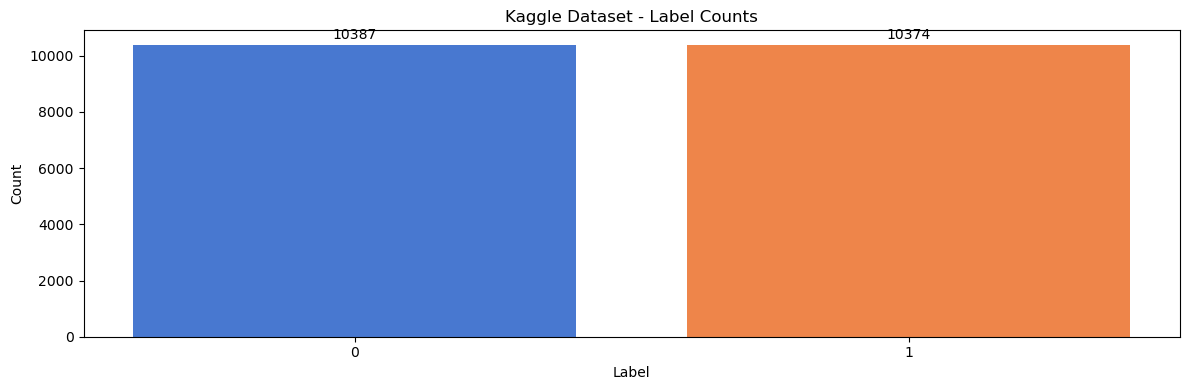

In [83]:
counts = kaggle_y.value_counts().sort_index()

fig, axes = plt.subplots(1, 1, figsize=(12, 4))

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

# Bar plot
colors = sns.color_palette("muted", n_colors=len(counts))
ax.bar(counts.index.astype(str), counts.values, color=colors)
ax.set_title("Kaggle Dataset - Label Counts")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.max() * 0.01, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

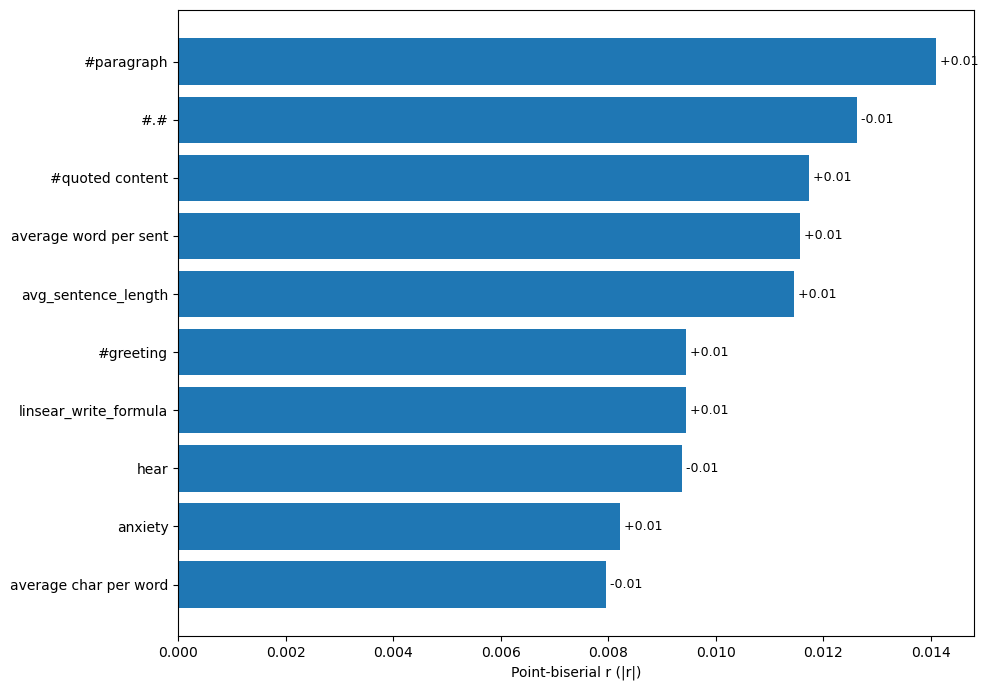

In [150]:
plot_top_linguistic_features(kaggle_lf, kaggle_y, top_n=10)

#### Word2Vec Embeddings

In [84]:
# Word2Vec model training and embedding extraction
kaggle_word2vec = Word2Vec(sentences=kaggle_tokenized, vector_size=100, window=5, min_count=1, workers=4)

kaggle_word_embeddings = np.array([np.mean([kaggle_word2vec.wv[word] for word in words if word in kaggle_word2vec.wv] or [np.zeros(100)], axis=0) for words in kaggle_tokenized])

In [85]:
# train-test split with combined features

X_combined = np.concatenate((kaggle_word_embeddings, kaggle_lf.values), axis=1)

X_train_w2v_kg, X_test_w2v_kg, y_train_w2v_kg, y_test_w2v_kg = create_train_test_split(X_combined, kaggle_y, random_state=42, test_size=0.3)

In [86]:
# checking the dimensions and potential issues
check_dataset(kaggle_word_embeddings, kaggle_lf, X_combined, y_train_w2v_kg)

Word embeddings shape: (20761, 100)
Linguistic features shape: (20761, 80)
Combined features shape: (20761, 180)
Training samples: 14532
Total features: 180
Features vs Samples ratio: 0.01

Checking for potential multicollinearity issues:
Any NaN values: False
Any infinite values: False
Features with very low variance (< 1e-10): 1
Condition number: 7.15e+17
High condition number suggests severe multicollinearity


##### Logistic Regression

In [131]:
kaggle_logit_model = train_logistic_regression(X_train_w2v_kg, y_train_w2v_kg, model_name="kaggle")
print(kaggle_logit_model)
print(kaggle_logit_model.penalty)

Loaded existing model from all_models/kaggle_logistic_regression.pkl
LogisticRegression(C=100, max_iter=1000, random_state=42)
l2


Accuracy: 0.9681
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      3138
           1       0.99      0.94      0.97      3091

    accuracy                           0.97      6229
   macro avg       0.97      0.97      0.97      6229
weighted avg       0.97      0.97      0.97      6229



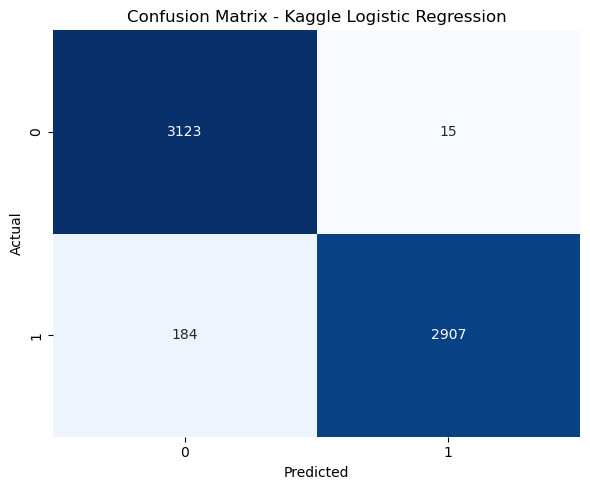

In [88]:
evaluate_model(kaggle_logit_model, X_test_w2v_kg, y_test_w2v_kg, model_name="Kaggle Logistic Regression")

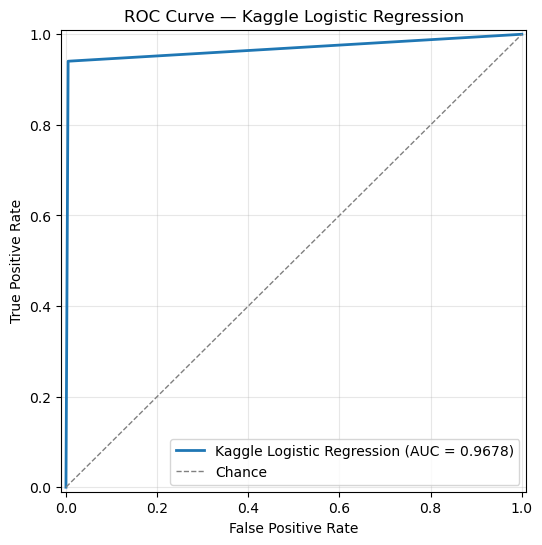

(array([0.        , 0.00478011, 1.        ]),
 array([0.        , 0.94047234, 1.        ]),
 0.967846112163049)

In [89]:
plot_auc_curve(kaggle_logit_model, X_test_w2v_kg, y_test_w2v_kg, "Kaggle Logistic Regression")

##### SVM

In [136]:
kaggle_svm_model = train_svm(X_train_w2v_kg, y_train_w2v_kg, model_name="kaggle")
print(kaggle_svm_model)
print(kaggle_svm_model.gamma)

Loaded existing model from all_models/kaggle_svm.pkl
SVC(C=10, kernel='linear', random_state=42)
scale


Accuracy: 0.9695
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      3138
           1       1.00      0.94      0.97      3091

    accuracy                           0.97      6229
   macro avg       0.97      0.97      0.97      6229
weighted avg       0.97      0.97      0.97      6229



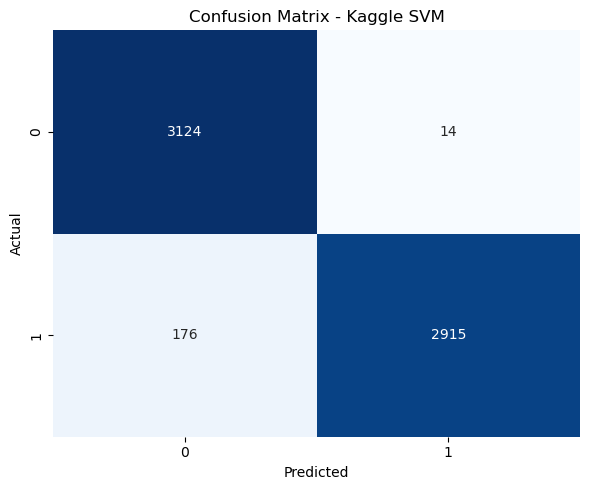

In [91]:
evaluate_model(kaggle_svm_model, X_test_w2v_kg, y_test_w2v_kg, model_name="Kaggle SVM")

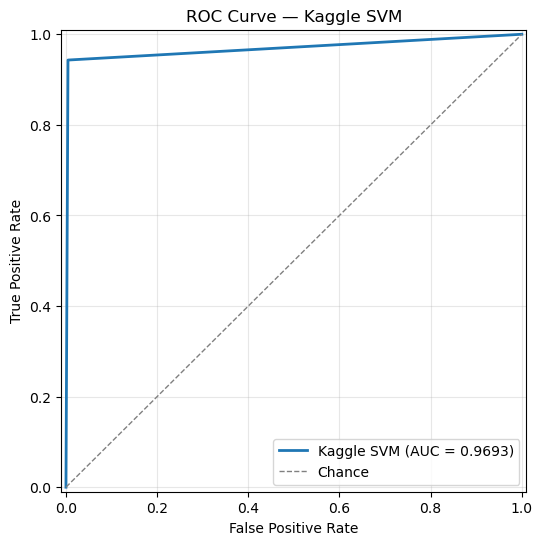

(array([0.        , 0.00446144, 1.        ]),
 array([0.       , 0.9430605, 1.       ]),
 0.9692995289063687)

In [92]:
plot_auc_curve(kaggle_svm_model, X_test_w2v_kg, y_test_w2v_kg, "Kaggle SVM")

##### XGBoost

In [141]:
kaggle_xgb_model = train_xgboost(X_train_w2v_kg, y_train_w2v_kg, model_name="kaggle")
print(kaggle_xgb_model)
print(kaggle_xgb_model.subsample)

Loaded existing model from all_models/kaggle_xgboost.pkl
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)
1.0


Accuracy: 0.9777
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3138
           1       1.00      0.96      0.98      3091

    accuracy                           0.98      6229
   macro avg       0.98      0.98      0.98      6229
weighted avg       0.98      0.98      0.98      6229



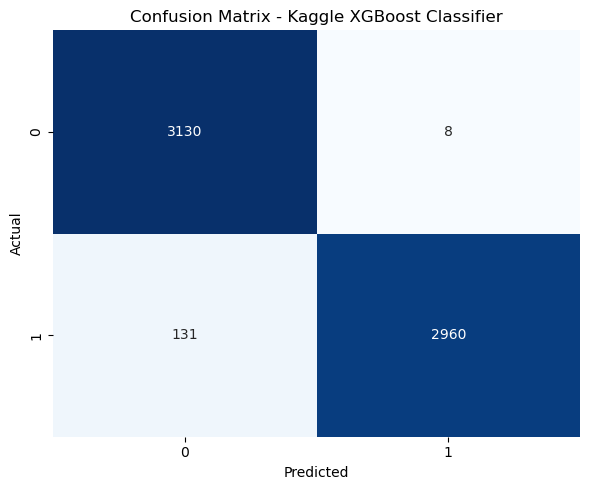

In [94]:
evaluate_model(kaggle_xgb_model, X_test_w2v_kg, y_test_w2v_kg, model_name="Kaggle XGBoost Classifier")

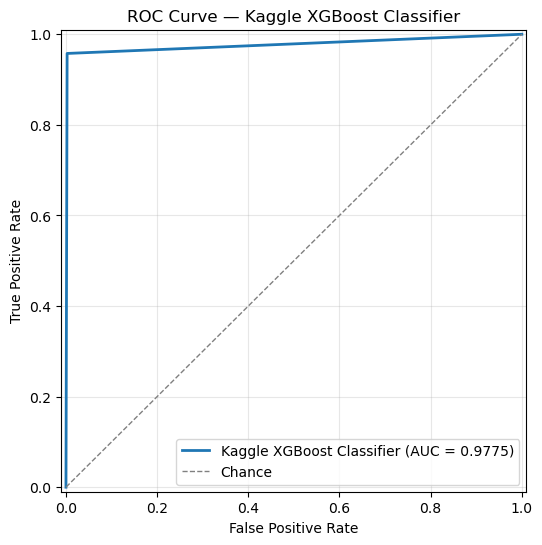

(array([0.        , 0.00254939, 1.        ]),
 array([0.        , 0.95761889, 1.        ]),
 0.9775347495215762)

In [95]:
plot_auc_curve(kaggle_xgb_model, X_test_w2v_kg, y_test_w2v_kg, "Kaggle XGBoost Classifier")

#### TFIDF Vectorizer Embeddings

In [96]:
kaggle_tfidf_vectorizer = TfidfVectorizer(max_features=5000, analyzer=lambda x: x)
kaggle_tfidf_embeddings = kaggle_tfidf_vectorizer.fit_transform(kaggle_tokenized).toarray()

In [97]:
X_combined = np.concatenate((kaggle_tfidf_embeddings, kaggle_lf.values), axis=1)

X_train_tfidf_kg, X_test_tfidf_kg, y_train_tfidf_kg, y_test_tfidf_kg = create_train_test_split(X_combined, kaggle_y, random_state=42, test_size=0.3)

##### Logistic Regression

In [132]:
kaggle_tfidf_logit_model = train_logistic_regression(X_train_tfidf_kg, y_train_tfidf_kg, model_name="kaggle_tfidf")
print(kaggle_tfidf_logit_model)
print(kaggle_tfidf_logit_model.penalty)

Loaded existing model from all_models/kaggle_tfidf_logistic_regression.pkl
LogisticRegression(C=100, max_iter=1000, random_state=42)
l2


Accuracy: 0.9892
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3138
           1       0.99      0.98      0.99      3091

    accuracy                           0.99      6229
   macro avg       0.99      0.99      0.99      6229
weighted avg       0.99      0.99      0.99      6229



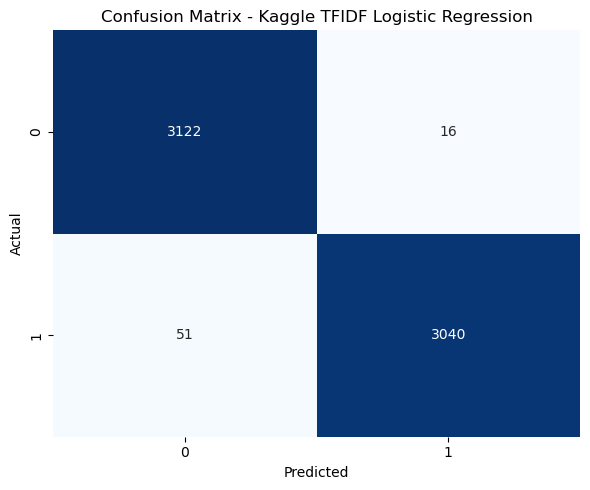

In [99]:
evaluate_model(kaggle_tfidf_logit_model, X_test_tfidf_kg, y_test_tfidf_kg, model_name="Kaggle TFIDF Logistic Regression")

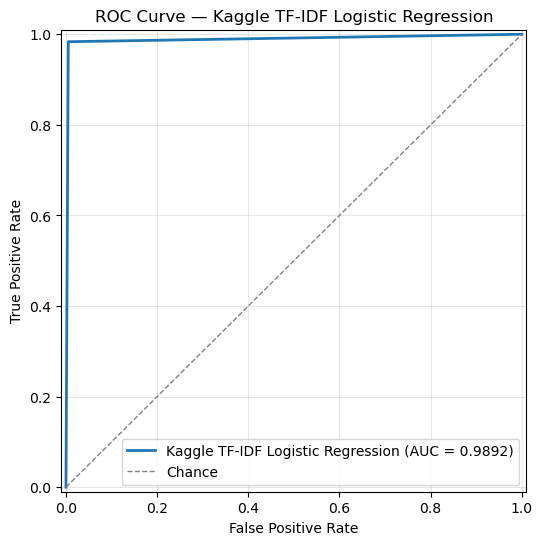

(array([0.        , 0.00509879, 1.        ]),
 array([0.        , 0.98350049, 1.        ]),
 0.9892008481211205)

In [100]:
plot_auc_curve(kaggle_tfidf_logit_model, X_test_tfidf_kg, y_test_tfidf_kg, "Kaggle TF-IDF Logistic Regression")

##### SVM

In [137]:
kaggle_svm_tfidf_model = train_svm(X_train_tfidf_kg, y_train_tfidf_kg, model_name="kaggle_tfidf")
print(kaggle_svm_tfidf_model)
print(kaggle_svm_tfidf_model.gamma)

Loaded existing model from all_models/kaggle_tfidf_svm.pkl
SVC(C=10, kernel='linear', random_state=42)
scale


Accuracy: 0.9897
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3138
           1       0.99      0.98      0.99      3091

    accuracy                           0.99      6229
   macro avg       0.99      0.99      0.99      6229
weighted avg       0.99      0.99      0.99      6229



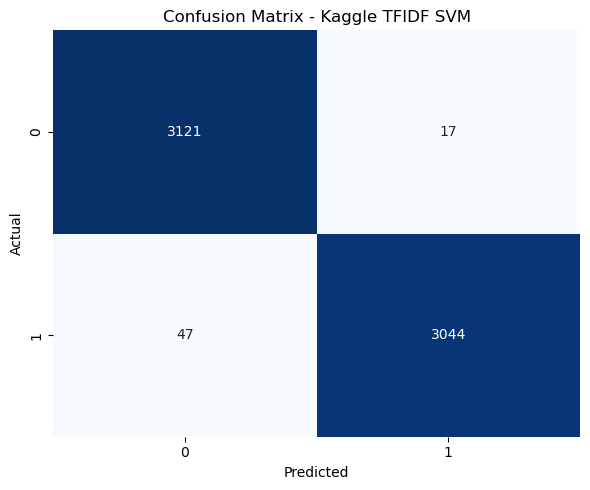

In [102]:
evaluate_model(kaggle_svm_tfidf_model, X_test_tfidf_kg, y_test_tfidf_kg, model_name="Kaggle TFIDF SVM")

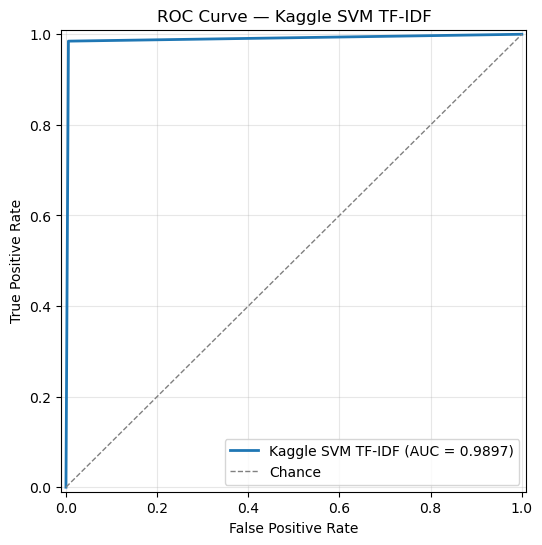

(array([0.        , 0.00541746, 1.        ]),
 array([0.        , 0.98479456, 1.        ]),
 0.9896885507566427)

In [103]:
plot_auc_curve(kaggle_svm_tfidf_model, X_test_tfidf_kg, y_test_tfidf_kg, "Kaggle SVM TF-IDF")

##### XGBoost Classifier

In [142]:
kaggle_xgb_tfidf_model = train_xgboost(X_train_tfidf_kg, y_train_tfidf_kg, model_name="kaggle_tfidf")
print(kaggle_xgb_tfidf_model)
print(kaggle_xgb_tfidf_model.subsample)

Loaded existing model from all_models/kaggle_tfidf_xgboost.pkl
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)
0.8


Accuracy: 0.9899
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3138
           1       1.00      0.98      0.99      3091

    accuracy                           0.99      6229
   macro avg       0.99      0.99      0.99      6229
weighted avg       0.99      0.99      0.99      6229



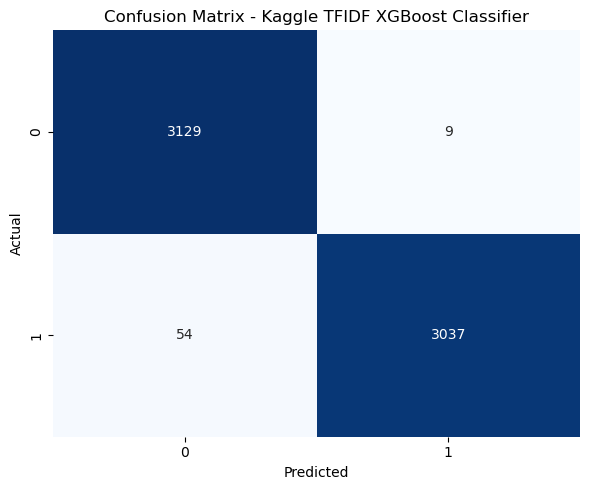

In [105]:
evaluate_model(kaggle_xgb_tfidf_model, X_test_tfidf_kg, y_test_tfidf_kg, model_name="Kaggle TFIDF XGBoost Classifier")

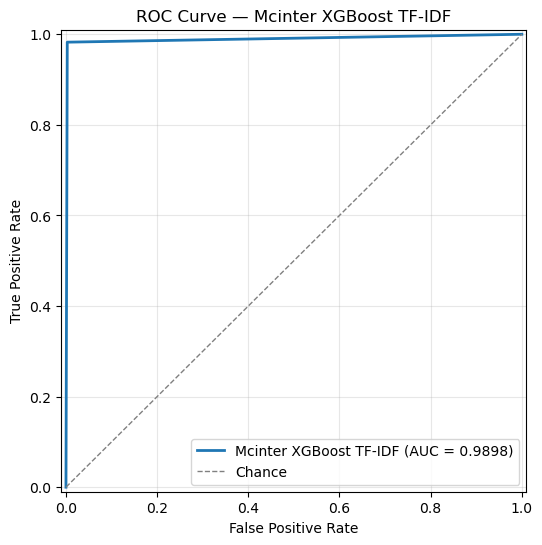

(array([0.        , 0.00286807, 1.        ]),
 array([0.        , 0.98252993, 1.        ]),
 0.9898309283783859)

In [106]:
plot_auc_curve(kaggle_xgb_tfidf_model, X_test_tfidf_kg, y_test_tfidf_kg, "Mcinter XGBoost TF-IDF")

##### Model Accuracy Comparison

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Kaggle Dataset - Model Accuracy Comparison'}, xlabel='Accuracy'>)

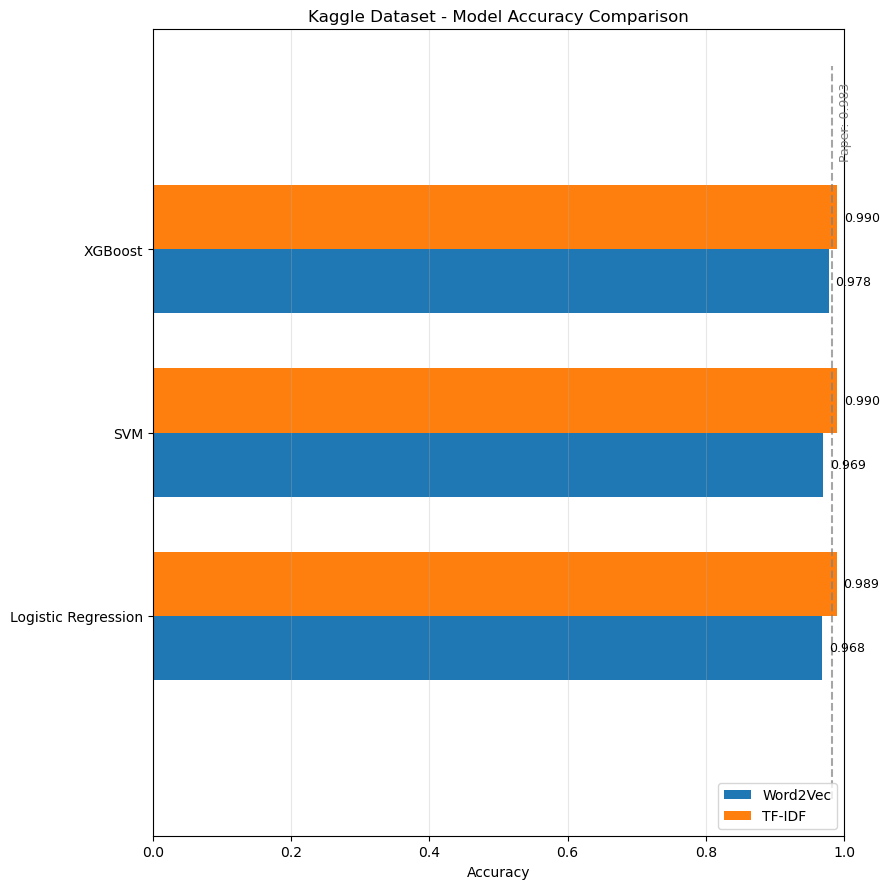

In [147]:
plot_model_accuracies(
    models_w2v=[kaggle_logit_model, kaggle_svm_model, kaggle_xgb_model],
    models_tfidf=[kaggle_tfidf_logit_model, kaggle_svm_tfidf_model, kaggle_xgb_tfidf_model],
    Xte_w2v=X_test_w2v_kg,
    Xte_tfidf=X_test_tfidf_kg,
    yte_w2v=y_test_w2v_kg,
    yte_tfidf=y_test_tfidf_kg,
    model_names=["Logistic Regression", "SVM", "XGBoost"],
    title="Kaggle Dataset - Model Accuracy Comparison",
    figsize=(9, 9),
    external_paper_accuracy=0.9825
)

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Kaggle Dataset - ROC Curves Comparison'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>)

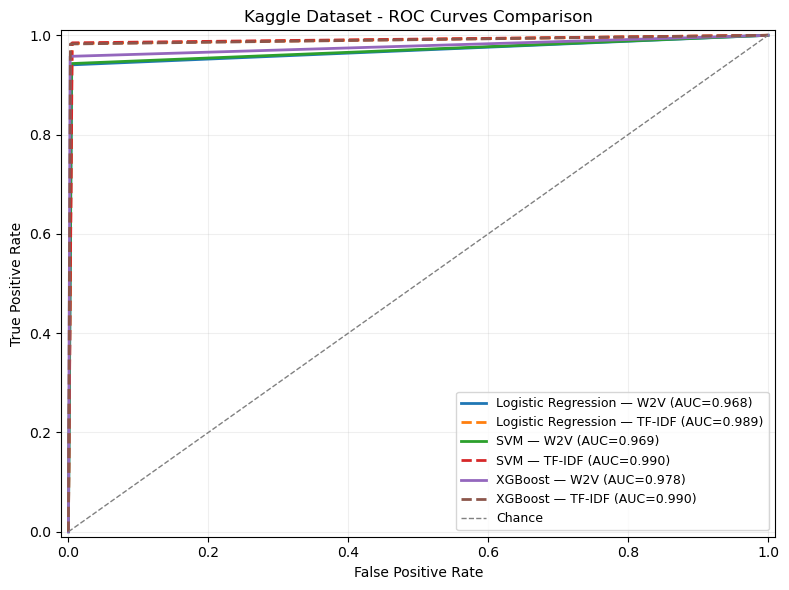

In [108]:
plot_model_aucs(
    models_w2v=[kaggle_logit_model, kaggle_svm_model, kaggle_xgb_model],
    models_tfidf=[kaggle_tfidf_logit_model, kaggle_svm_tfidf_model, kaggle_xgb_tfidf_model],
    Xte_w2v=X_test_w2v_kg,
    Xte_tfidf=X_test_tfidf_kg,
    yte_w2v=y_test_w2v_kg,
    yte_tfidf=y_test_tfidf_kg,
    model_names=["Logistic Regression", "SVM", "XGBoost"],
    title="Kaggle Dataset - ROC Curves Comparison"
)

## GenAI Prompted Improvement Strategies

The following section attempts to improve on the existing paper by utilizing a transformer backbone. Further details about the prompts can be looked at in the report.

Due to time constraints with model training, this improvement strategy has only been applied to the mcintire dataset.

### Dataset Loader

In [109]:
def load_dataframe(csv_path: str, lf_path: str, join_key: str | None = None) -> pd.DataFrame:
    """
    Returns a DataFrame with columns:
      ['text', 'label', 'lf_0', 'lf_1', ..., 'lf_{N-1}']

    - Reads raw text + label from CSV.
    - Reads linguistic features (LFs) from Excel.
    - Aligns by `join_key` if provided, otherwise by row order.
    - Keeps only numeric LF columns and renames to lf_0..lf_{N-1}.
    - Drops rows with missing text/label.
    """
    # --- Load core data (raw text; no cleaning) ---
    base_cols = ["text", "label"] + ([join_key] if join_key else [])
    df = pd.read_csv(csv_path, usecols=base_cols).dropna(subset=["text", "label"]).reset_index(drop=True)
    df["text"] = df["text"].astype(str)
    df["label"] = df["label"].astype(int)

    # --- Load LFs ---
    lf_df = pd.read_excel(lf_path).reset_index(drop=True)

    # Align by key if provided, otherwise by row order
    if join_key:
        if join_key not in df.columns or join_key not in lf_df.columns:
            raise ValueError(f"`join_key='{join_key}'` must exist in both files.")
        merged = df.merge(lf_df, on=join_key, how="inner", validate="one_to_one")
        # Keep original order of df after merge
        order = pd.Categorical(merged[join_key], categories=df[join_key], ordered=True)
        merged = merged.sort_values(join_key, key=lambda s: order).reset_index(drop=True)
        text = merged["text"]
        label = merged["label"]
        lf_df = merged.drop(columns=[join_key, "text", "label"])
    else:
        if len(df) != len(lf_df):
            raise ValueError("Row counts differ; provide a `join_key` to align.")
        text = df["text"]
        label = df["label"]

    # Keep only numeric LFs; drop any accidental label/ID columns
    lf_num = lf_df.select_dtypes(include=[np.number]).copy()
    for bad in ["label", "Label", "y", "target", "Target"]:
        if bad in lf_num.columns:
            lf_num.drop(columns=[bad], inplace=True)

    if lf_num.shape[1] == 0:
        raise ValueError("No numeric LF columns found in lf_path.")

    # Standardize LF column names
    lf_num.columns = [f"lf_{i}" for i in range(lf_num.shape[1])]

    out = pd.concat([text.rename("text"), label.rename("label"), lf_num], axis=1).reset_index(drop=True)
    return out

### Configuration Class

In [110]:
# ========================= Config =========================
@dataclass
class Config:
    TRANSFORMER: str = "roberta-base"                 # long-context; fallback: "distilroberta-base"
    MAX_LEN: int = 510                                # 4096 possible for some long models, mind VRAM
    N_LF: int = 80                                    # number of linguistic features you have
    TEXT_DROPOUT: float = 0.2
    LF_DROPOUT: float = 0.3
    FUSE_DROPOUT: float = 0.3
    HIDDEN_TEXT: int = 768                            # depends on backbone; auto-detected later
    HIDDEN_LF: int = 128
    HIDDEN_FUSE: int = 256
    LABEL_SMOOTHING: float = 0.05
    BATCH_SIZE: int = 16                              # tune based on VRAM; gradient_accumulation if needed
    EPOCHS_HEAD: int = 2                              # phase 1: freeze transformer
    EPOCHS_FULL: int = 5                              # phase 2: unfreeze and fine-tune
    WARMUP_STEPS: int = 500
    TOTAL_STEPS: int = 5000                           # steps for cosine schedule (roughly epochs * steps/epoch)
    LR_MAX: float = 2e-5                              # peak LR for Transformer
    WD: float = 0.01                                  # AdamW weight decay
    EARLY_STOP_PATIENCE: int = 2
    VAL_SPLIT: float = 0.1
    TEST_SPLIT: float = 0.1

CFG = Config()

### Helper Methods

In [111]:
def tokenize_texts(tokenizer, texts: np.ndarray) -> Dict[str, np.ndarray]:
    enc = tokenizer(
        list(texts),
        truncation=True,
        padding="max_length",
        max_length=CFG.MAX_LEN,
        return_attention_mask=True,
        return_tensors="np",
    )
    return {"input_ids": enc["input_ids"], "attention_mask": enc["attention_mask"]}

In [112]:
# ========================= Splits & Scaling =========================
def make_splits(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    dtrain, dtemp = train_test_split(df, test_size=CFG.VAL_SPLIT + CFG.TEST_SPLIT,
                                     stratify=df["label"], random_state=SEED)
    rel = CFG.TEST_SPLIT / (CFG.VAL_SPLIT + CFG.TEST_SPLIT)
    dval, dtest = train_test_split(dtemp, test_size=rel,
                                   stratify=dtemp["label"], random_state=SEED)
    return dtrain.reset_index(drop=True), dval.reset_index(drop=True), dtest.reset_index(drop=True)

def scale_lfs(dtrain, dval, dtest) -> Tuple[np.ndarray, np.ndarray, np.ndarray, StandardScaler]:
    lf_cols = [f"lf_{i}" for i in range(CFG.N_LF)]
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(dtrain[lf_cols].values.astype("float32"))
    Xva = scaler.transform(dval[lf_cols].values.astype("float32"))
    Xte = scaler.transform(dtest[lf_cols].values.astype("float32"))
    return Xtr, Xva, Xte, scaler

In [113]:
# ========================= tf.data pipelines =========================
def make_tfds(tokenizer, dtrain, dval, dtest):
    Xtr_lf, Xva_lf, Xte_lf, _ = scale_lfs(dtrain, dval, dtest)
    ytr = dtrain["label"].values.astype("int32")
    yva = dval["label"].values.astype("int32")
    yte = dtest["label"].values.astype("int32")

    tr_tokens = tokenize_texts(tokenizer, dtrain["text"].values)
    va_tokens = tokenize_texts(tokenizer, dval["text"].values)
    te_tokens = tokenize_texts(tokenizer, dtest["text"].values)

    def make_ds(tokens, lfs, y, shuffle=False):
        ds = tf.data.Dataset.from_tensor_slices((
            {"input_ids": tokens["input_ids"],
             "attention_mask": tokens["attention_mask"],
             "lfs": lfs},
            y
        ))
        if shuffle:
            ds = ds.shuffle(buffer_size=8192, seed=SEED, reshuffle_each_iteration=True)
        ds = ds.batch(CFG.BATCH_SIZE, drop_remainder=False).prefetch(tf.data.AUTOTUNE)
        return ds

    train_ds = make_ds(tr_tokens, Xtr_lf, ytr, shuffle=True)
    val_ds   = make_ds(va_tokens, Xva_lf, yva, shuffle=False)
    test_ds  = make_ds(te_tokens, Xte_lf, yte, shuffle=False)
    return train_ds, val_ds, test_ds

In [114]:
# ========================= LR Schedule (Warmup + Cosine) =========================
class WarmupCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, lr_max, warmup_steps, total_steps, name=None):
        super().__init__()
        # store python-native types for clean serialization
        self.lr_max = float(lr_max)
        self.warmup_steps = int(warmup_steps)
        self.total_steps = int(total_steps)
        self.name = name or "WarmupCosine"

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)
        total_steps  = tf.cast(self.total_steps, tf.float32)
        lr_max = tf.cast(self.lr_max, tf.float32)

        # Warmup
        warmup_lr = lr_max * (step / tf.maximum(1.0, warmup_steps))
        # Cosine decay
        progress = tf.clip_by_value(
            (step - warmup_steps) / tf.maximum(1.0, total_steps - warmup_steps),
            0.0, 1.0
        )
        cosine_lr = 0.5 * lr_max * (1 + tf.cos(math.pi * progress))
        return tf.where(step < warmup_steps, warmup_lr, cosine_lr)

    # >>> This makes it Keras-serializable
    def get_config(self):
        return {
            "lr_max": self.lr_max,
            "warmup_steps": self.warmup_steps,
            "total_steps": self.total_steps,
            "name": self.name,
        }

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [115]:
# ========================= Metrics =========================
class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name="f1", threshold=0.5, **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.tp = self.add_weight(name="tp", initializer="zeros")
        self.fp = self.add_weight(name="fp", initializer="zeros")
        self.fn = self.add_weight(name="fn", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(y_pred >= self.threshold, tf.float32)
        y_true = tf.cast(y_true, tf.float32)
        tp = tf.reduce_sum(y_true * y_pred)
        fp = tf.reduce_sum((1 - y_true) * y_pred)
        fn = tf.reduce_sum(y_true * (1 - y_pred))
        self.tp.assign_add(tp); self.fp.assign_add(fp); self.fn.assign_add(fn)

    def result(self):
        precision = self.tp / (self.tp + self.fp + 1e-7)
        recall    = self.tp / (self.tp + self.fn + 1e-7)
        f1        = 2 * precision * recall / (precision + recall + 1e-7)
        return f1

    def reset_states(self):
        for v in (self.tp, self.fp, self.fn):
            v.assign(0.0)

In [116]:
# ========================= Model =========================
def build_model() -> tf.keras.Model:
    # Transformer backbone (TF-native)
    transformer = TFRobertaModel.from_pretrained(CFG.TRANSFORMER, from_pt=True)
    hidden_size = int(transformer.config.hidden_size)

    # Inputs
    ids_in   = tf.keras.layers.Input(shape=(CFG.MAX_LEN,), dtype=tf.int32, name="input_ids")
    mask_in  = tf.keras.layers.Input(shape=(CFG.MAX_LEN,), dtype=tf.int32, name="attention_mask")
    lfs_in   = tf.keras.layers.Input(shape=(CFG.N_LF,), dtype=tf.float32, name="lfs")

    # Text tower
    outputs = transformer(input_ids=ids_in, attention_mask=mask_in, training=True)
    cls = outputs.last_hidden_state[:, 0, :]  # CLS
    x_text = tf.keras.layers.Dropout(CFG.TEXT_DROPOUT)(cls)
    x_text = tf.keras.layers.Dense(hidden_size, activation="gelu", name="text_proj")(x_text)

    # LF tower
    x_lf = tf.keras.layers.LayerNormalization()(lfs_in)
    x_lf = tf.keras.layers.Dense(CFG.HIDDEN_LF, activation="gelu")(x_lf)
    x_lf = tf.keras.layers.Dropout(CFG.LF_DROPOUT)(x_lf)
    x_lf = tf.keras.layers.Dense(CFG.HIDDEN_LF, activation="gelu")(x_lf)

    # Late fusion (FiLM-style gate)
    gate = tf.keras.layers.Dense(hidden_size, activation="sigmoid", name="lf_gate")(x_lf)
    gated_text = tf.keras.layers.Multiply(name="gated_text")([x_text, gate])
    fused = tf.keras.layers.Concatenate(name="fuse_concat")([gated_text, x_lf])
    fused = tf.keras.layers.Dropout(CFG.FUSE_DROPOUT)(fused)
    fused = tf.keras.layers.Dense(CFG.HIDDEN_FUSE, activation="gelu")(fused)
    fused = tf.keras.layers.Dropout(CFG.FUSE_DROPOUT)(fused)

    # Classifier
    logits = tf.keras.layers.Dense(1, dtype="float32", name="logits")(fused)
    probs  = tf.keras.layers.Activation("sigmoid", name="prob")(logits)

    model = tf.keras.Model(
        inputs={"input_ids": ids_in, "attention_mask": mask_in, "lfs": lfs_in},
        outputs=probs,
        name="Roberta_LF_LateFusion"
    )
    model.transformer = transformer
    return model

In [117]:
# ========================= Compile & Train =========================
MODEL_DIR = Path("all_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)


def compile_model(model, trainable_transformer: bool, steps_per_epoch: int):
    model.transformer.trainable = trainable_transformer

    lr_sched = WarmupCosine(CFG.LR_MAX, CFG.WARMUP_STEPS, CFG.TOTAL_STEPS)
    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=lr_sched, decay=CFG.WD, clipnorm=1.0)
    loss = tf.keras.losses.BinaryCrossentropy(label_smoothing=CFG.LABEL_SMOOTHING)
    metrics = [
        tf.keras.metrics.AUC(curve="ROC", name="auc"),
        tf.keras.metrics.AUC(curve="PR", name="auprc"),
        F1Score(name="f1"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.BinaryAccuracy(name="acc", threshold=0.5),
    ]
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    return model

def load_model_if_exists():
    """Return a compiled model if bundle exists, else None."""
    keras_path = MODEL_DIR / "best_model.keras"
    if keras_path.exists():
        model = build_model()
        model.load_weights(keras_path)
        print(f"[loaded] {keras_path.name}")
        return model
    return None

def class_weights_from_ds(labels: np.ndarray) -> Dict[int, float]:
    # Inverse-frequency weighting
    pos = labels.sum()
    neg = len(labels) - pos
    total = len(labels)
    w0 = total / (2.0 * neg + 1e-7)
    w1 = total / (2.0 * pos + 1e-7)
    return {0: float(w0), 1: float(w1)}

def train(train_ds, val_ds, y_train: np.ndarray) -> tf.keras.Model:
    loaded = load_model_if_exists()
    if loaded is not None:
        return loaded

    steps_per_epoch = int(np.ceil(len(y_train) / CFG.BATCH_SIZE))
    model = build_model()

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max",
            patience=CFG.EARLY_STOP_PATIENCE, restore_best_weights=True
        ),
        tf.keras.callbacks.ModelCheckpoint(
            "all_models/best_model.keras", monitor="val_auc", mode="max",
            save_best_only=True, save_weights_only=True
        ),
    ]
    cw = class_weights_from_ds(y_train)

    # Phase 1: freeze encoder
    compile_model(model, trainable_transformer=False, steps_per_epoch=steps_per_epoch)
    model.fit(train_ds, validation_data=val_ds, epochs=CFG.EPOCHS_HEAD,
              class_weight=cw, callbacks=callbacks, verbose=1)

    # Phase 2: unfreeze encoder
    model.transformer.trainable = True
    compile_model(model, trainable_transformer=True, steps_per_epoch=steps_per_epoch)
    model.fit(train_ds, validation_data=val_ds, epochs=CFG.EPOCHS_FULL,
              class_weight=cw, callbacks=callbacks, verbose=1)

    return model

### Model Training

In [118]:
# 1) Load
df = load_dataframe(
    csv_path="Dataset/Mcintire_DataSet.csv",
    lf_path="Dataset/linguistic_features/arrays_Mcintire.xlsx",
)
tokenizer = RobertaTokenizer.from_pretrained("roberta-base", use_fast=False)

In [119]:
# 2) Split
dtrain, dval, dtest = make_splits(df)

# 3) tf.data
train_ds, val_ds, test_ds = make_tfds(tokenizer, dtrain, dval, dtest)

In [120]:
# 4) Train
model = train(train_ds, val_ds, dtrain["label"].values.astype("int32"))

[loaded] best_model.keras


### Model Evaluation

In [121]:
model.summary()

Model: "Roberta_LF_LateFusion"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 lfs (InputLayer)            [(None, 80)]                 0         []                            
                                                                                                  
 input_ids (InputLayer)      [(None, 510)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 510)]                0         []                            
 )                                                                                                
                                                                                                  
 layer_normalization (Layer  (None, 80)                   160       ['lfs[0][0

40/40 [==============================] - 192s 5s/step
Accuracy: 0.9968
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       317
           1       0.99      1.00      1.00       317

    accuracy                           1.00       634
   macro avg       1.00      1.00      1.00       634
weighted avg       1.00      1.00      1.00       634



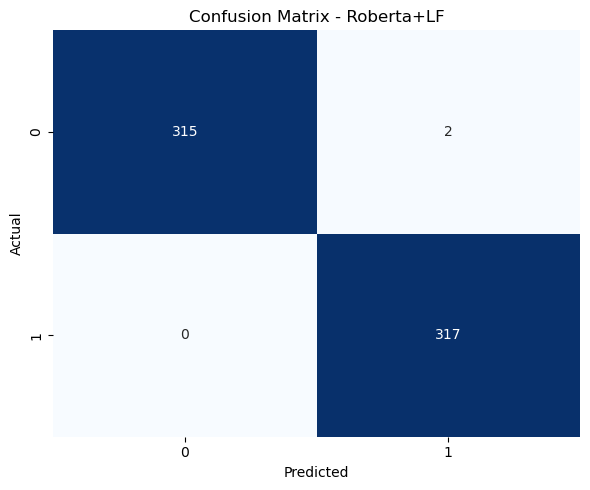

In [122]:
evaluate_model(model, test_ds, dtest["label"].values.astype("int32"), model_name="Roberta+LF")

40/40 [==============================] - 203s 5s/step


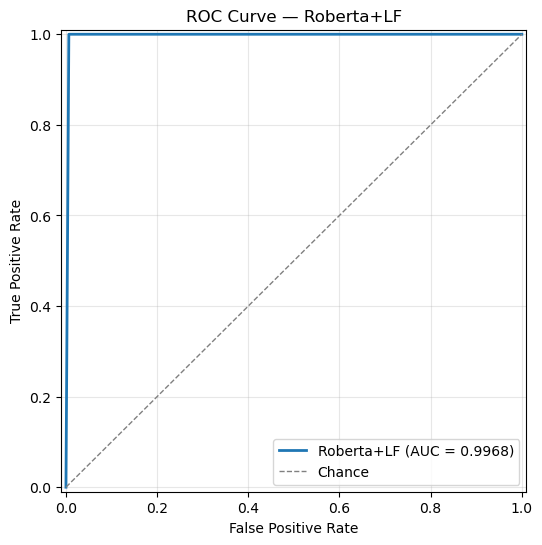

(array([0.        , 0.00630915, 1.        ]),
 array([0., 1., 1.]),
 0.9968454258675079)

In [123]:
plot_auc_curve(model, test_ds, dtest["label"].values.astype("int32"), "Roberta+LF")

## All Models Comparison

40/40 [==============================] - 207s 5s/step


(<Figure size 1200x735 with 1 Axes>,
 <Axes: title={'center': 'All Models - Accuracy Comparison'}, xlabel='Accuracy'>,
 array([0.99369085, 0.98988602, 0.98972548, 0.98924386, 0.97768502,
        0.96949751, 0.96805266, 0.96528143, 0.95370857, 0.94844819,
        0.93897948, 0.93792741, 0.92477643]))

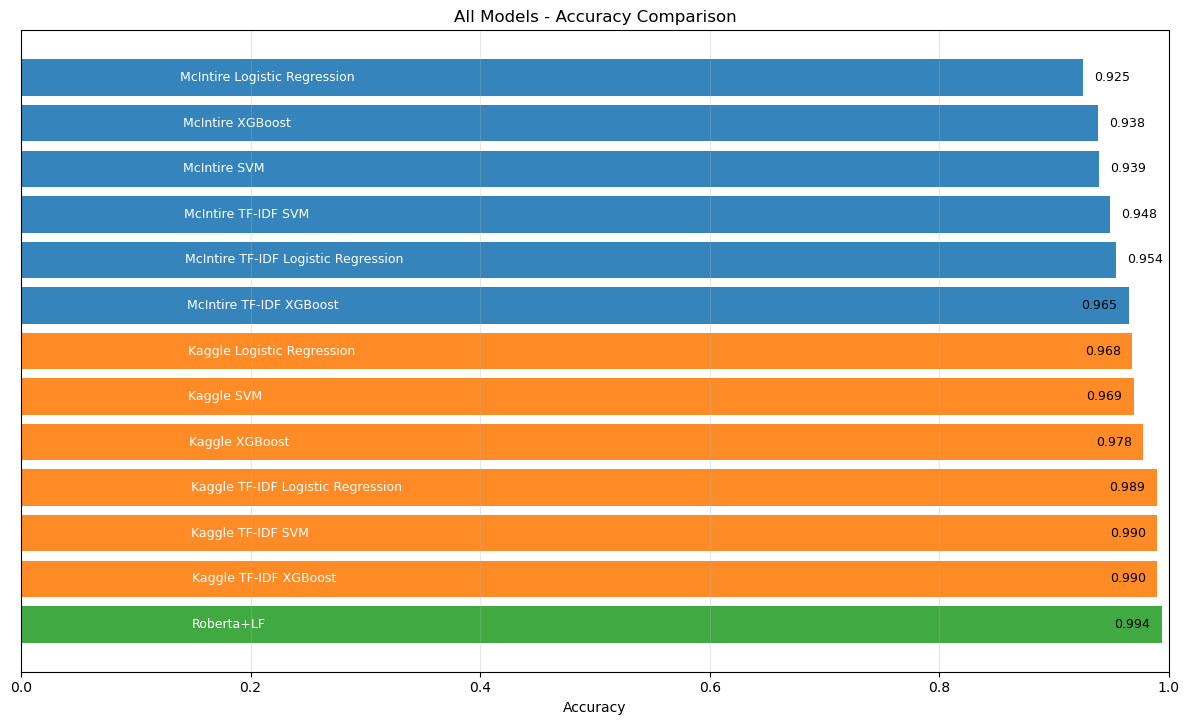

In [124]:
# plot all model accuracies
plot_model_accuracies_ranked(
    models_by_dataset = [[
        mcinter_logit_model, mcinter_svm_model, mcinter_xgb_model,
        mcinter_tfidf_logit_model, mcinter_svm_tfidf_model, mcinter_xgb_tfidf_model
    ], [
        kaggle_logit_model, kaggle_svm_model, kaggle_xgb_model,
        kaggle_tfidf_logit_model, kaggle_svm_tfidf_model, kaggle_xgb_tfidf_model
    ], [
        model  # Roberta+LF on Mcintire
    ]],
    Xte_by_dataset = [[
        X_test_w2v_mc, X_test_w2v_mc, X_test_w2v_mc,
        X_test_tfidf_mc, X_test_tfidf_mc, X_test_tfidf_mc
    ], [
        X_test_w2v_kg, X_test_w2v_kg, X_test_w2v_kg,
        X_test_tfidf_kg, X_test_tfidf_kg, X_test_tfidf_kg
    ], [
        test_ds  # Roberta+LF on Mcintire
    ]],
    yte_by_dataset = [[
        y_test_w2v_mc, y_test_w2v_mc, y_test_w2v_mc,
        y_test_tfidf_mc, y_test_tfidf_mc, y_test_tfidf_mc
    ], [
        y_test_w2v_kg, y_test_w2v_kg, y_test_w2v_kg,
        y_test_tfidf_kg, y_test_tfidf_kg, y_test_tfidf_kg
    ], [
        dtest["label"].values.astype("int32")  # Roberta+LF on Mcintire
    ]],
    model_names = [
        ["McIntire Logistic Regression", "McIntire SVM", "McIntire XGBoost",
         "McIntire TF-IDF Logistic Regression", "McIntire TF-IDF SVM", "McIntire TF-IDF XGBoost"],
        ["Kaggle Logistic Regression", "Kaggle SVM", "Kaggle XGBoost",
         "Kaggle TF-IDF Logistic Regression", "Kaggle TF-IDF SVM", "Kaggle TF-IDF XGBoost"],
        ["Roberta+LF"]
    ],
    title = "All Models - Accuracy Comparison",
)

## Testing OOD performance of the models

I will take the best performing model that I trained on mcintire dataset, and evaluate it on the kaggle dataset.
Then I will evaluate the performance of the model given by GenAI on the kaggle dataset.

This would give me an idea about the OOD performance between the models.

Accuracy: 0.1965
Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.26      0.25      3138
           1       0.15      0.13      0.14      3091

    accuracy                           0.20      6229
   macro avg       0.19      0.20      0.19      6229
weighted avg       0.19      0.20      0.19      6229



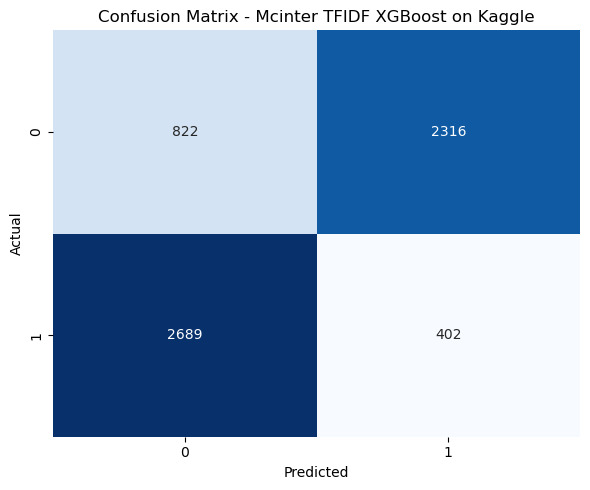

In [125]:
evaluate_model(mcinter_xgb_tfidf_model, X_test_tfidf_kg, y_test_tfidf_kg, model_name="Mcinter TFIDF XGBoost on Kaggle")

In [126]:
kaggle_df = load_dataframe(
    csv_path="Dataset/Kaggle.csv",
    lf_path="Dataset/linguistic_features/arrays_kaggle.xlsx",
)

dtrain_kaggle, dval_kaggle, dtest_kaggle = make_splits(kaggle_df)

train_ds_kaggle, val_ds_kaggle, test_ds_kaggle = make_tfds(tokenizer, dtrain_kaggle, dval_kaggle, dtest_kaggle)

130/130 [==============================] - 678s 5s/step
Accuracy: 0.5291
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.07      0.13      1039
           1       0.52      0.99      0.68      1038

    accuracy                           0.53      2077
   macro avg       0.68      0.53      0.40      2077
weighted avg       0.68      0.53      0.40      2077



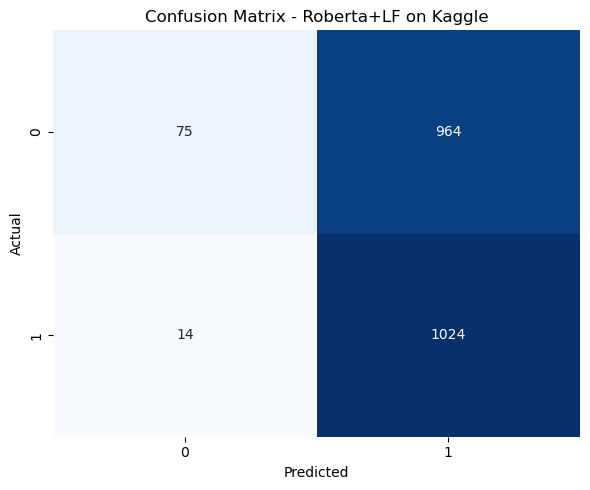

In [127]:
evaluate_model(model, test_ds_kaggle, dtest_kaggle["label"].values.astype("int32"), model_name="Roberta+LF on Kaggle")